# Notebook 01 — Single Factor Beta Decomposition

## Objective
Decompose each stock's risk into **systematic risk** (driven by the market) and **idiosyncratic risk** (stock-specific) using the CAPM single-factor model.

## The Model
$$R_i = \alpha_i + \beta_i \cdot R_m + \epsilon_i$$

Where:
- $R_i$ = return of stock $i$
- $R_m$ = market return (S&P 500)
- $\beta_i$ = sensitivity to market (systematic exposure)
- $\alpha_i$ = excess return above market
- $\epsilon_i$ = idiosyncratic (unexplained) return

## Variance Decomposition
$$\text{Total Variance} = \beta_i^2 \cdot \sigma_m^2 + \sigma_{\epsilon_i}^2$$

- **Systematic Variance** = $\beta_i^2 \cdot \sigma_m^2$
- **Idiosyncratic Variance** = $\sigma_{\epsilon_i}^2$

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme — applied once globally ───────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor'  : '#0D0D0D',
    'axes.facecolor'    : '#0D0D0D',
    'axes.edgecolor'    : '#444444',
    'axes.labelcolor'   : '#CCCCCC',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#AAAAAA',
    'ytick.color'       : '#AAAAAA',
    'grid.color'        : '#2A2A2A',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1A1A1A',
    'legend.edgecolor'  : '#444444',
    'legend.labelcolor' : '#CCCCCC',
    'text.color'        : '#FFFFFF',
    'font.size'         : 10,
})

# ── Portfolio Configuration ───────────────────────────────────────────────────
TICKERS      = ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN']
MARKET       = '^GSPC'
START        = '2018-01-01'
END          = '2024-01-01'

# Bright colors that pop on dark background
COLORS       = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300']
STOCK_COLORS = dict(zip(TICKERS, COLORS))

print(f"Portfolio : {TICKERS}")
print(f"Period    : {START} → {END}")
print(f"Market    : S&P 500 ({MARKET})")

Portfolio : ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN']
Period    : 2018-01-01 → 2024-01-01
Market    : S&P 500 (^GSPC)


## 2. Download Data

In [2]:
raw       = yf.download(TICKERS + [MARKET], start=START, end=END)['Close']
prices    = raw[TICKERS]
market_px = raw[MARKET]

returns  = np.log(prices / prices.shift(1)).dropna()
mkt_ret  = np.log(market_px / market_px.shift(1)).dropna()

returns, mkt_ret = returns.align(mkt_ret, join='inner', axis=0)

print(f"Data shape : {returns.shape}")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
returns.head()

[*********************100%***********************]  6 of 6 completed

Data shape : (1508, 5)
Date range : 2018-01-03 → 2023-12-29


Ticker,AAPL,JPM,XOM,JNJ,AMZN
Date,,,,,
2018-01-03,-0.000174,0.001018,0.019450,0.009507,0.012694
2018-01-04,0.004635,0.014224,0.001383,-0.000071,0.004466
2018-01-05,0.011321,-0.006441,-0.000806,0.008220,0.016033
2018-01-08,-0.003722,0.001476,0.004486,0.001269,0.014322
2018-01-09,-0.000115,0.005056,-0.004256,0.015733,0.004665


## 3. OLS Regression — Beta & Alpha for Each Stock

In [3]:
def run_capm(stock_returns, market_returns):
    X         = sm.add_constant(market_returns)
    model     = sm.OLS(stock_returns, X).fit()
    alpha     = model.params['const']
    beta      = model.params[market_returns.name if hasattr(market_returns, 'name') else 0]
    r_squared = model.rsquared
    residuals = model.resid
    total_var = stock_returns.var()
    sys_var   = (beta ** 2) * market_returns.var()
    idio_var  = residuals.var()
    return {
        'alpha'     : alpha,
        'beta'      : beta,
        'r_squared' : r_squared,
        'total_var' : total_var,
        'sys_var'   : sys_var,
        'idio_var'  : idio_var,
        'sys_pct'   : sys_var  / total_var * 100,
        'idio_pct'  : idio_var / total_var * 100,
        'residuals' : residuals,
        'model'     : model
    }

mkt_series      = mkt_ret.squeeze()
mkt_series.name = 'market'

results = {t: run_capm(returns[t], mkt_series) for t in TICKERS}

summary = pd.DataFrame({
    'Beta'            : {t: results[t]['beta']      for t in TICKERS},
    'Alpha (daily)'   : {t: results[t]['alpha']     for t in TICKERS},
    'R²'              : {t: results[t]['r_squared'] for t in TICKERS},
    'Systematic %'    : {t: results[t]['sys_pct']   for t in TICKERS},
    'Idiosyncratic %' : {t: results[t]['idio_pct']  for t in TICKERS},
}).round(4)

print("\n── CAPM Regression Summary ─────────────────────────────")
print(summary.to_string())


── CAPM Regression Summary ─────────────────────────────
        Beta  Alpha (daily)      R²  Systematic %  Idiosyncratic %
AAPL  1.2176         0.0006  0.6358       63.5830          36.4170
JPM   1.0861         0.0000  0.5482       54.8215          45.1785
XOM   0.8867        -0.0000  0.3194       31.9427          68.0573
JNJ   0.5475        -0.0000  0.3146       31.4608          68.5392
AMZN  1.1256         0.0002  0.4363       43.6308          56.3692


## 4. Visualisations

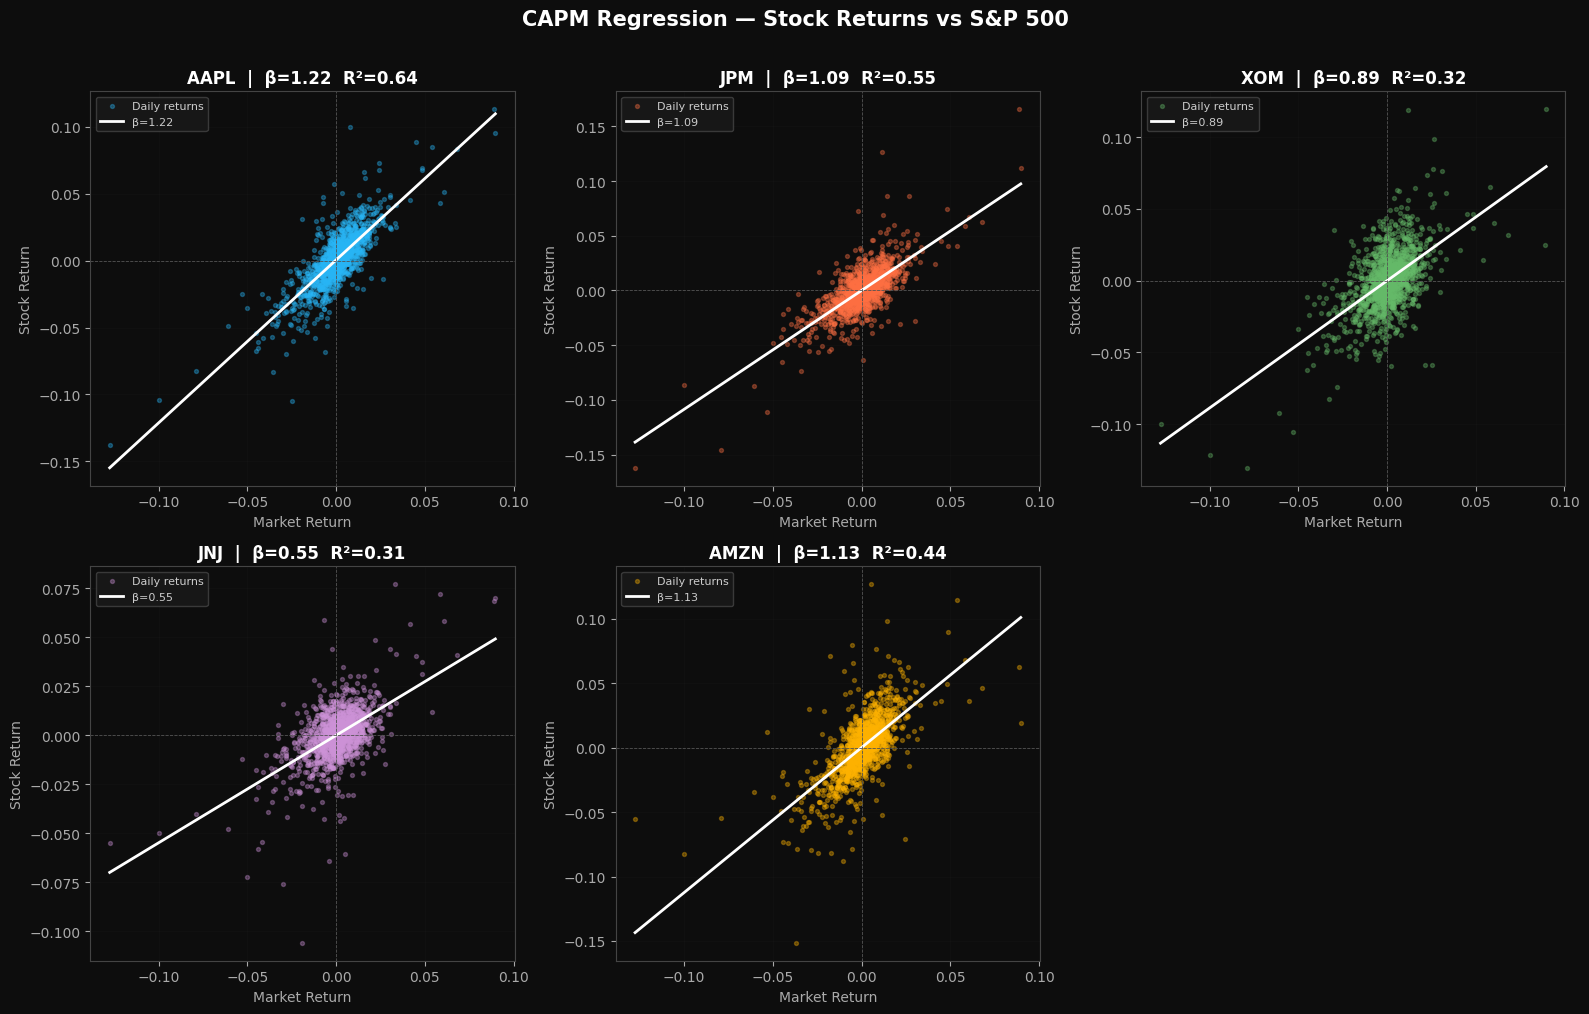

In [4]:
# ── Plot 1: Scatter — each stock vs S&P 500 ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes      = axes.flatten()
fig.suptitle('CAPM Regression — Stock Returns vs S&P 500',
             fontsize=15, fontweight='bold', y=1.01, color='white')
fig.patch.set_facecolor('#0D0D0D')

for i, ticker in enumerate(TICKERS):
    ax  = axes[i]
    res = results[ticker]
    x   = mkt_series.values
    y   = returns[ticker].values

    ax.scatter(x, y, alpha=0.35, s=8,
               color=STOCK_COLORS[ticker], label='Daily returns')

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = res['alpha'] + res['beta'] * x_line
    ax.plot(x_line, y_line, color='white', linewidth=2,
            label=f"β={res['beta']:.2f}")

    ax.axhline(0, color='#555555', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='#555555', linewidth=0.6, linestyle='--')
    ax.set_title(f"{ticker}  |  β={res['beta']:.2f}  R²={res['r_squared']:.2f}",
                 fontweight='bold', color='white')
    ax.set_xlabel('Market Return', color='#AAAAAA')
    ax.set_ylabel('Stock Return',  color='#AAAAAA')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


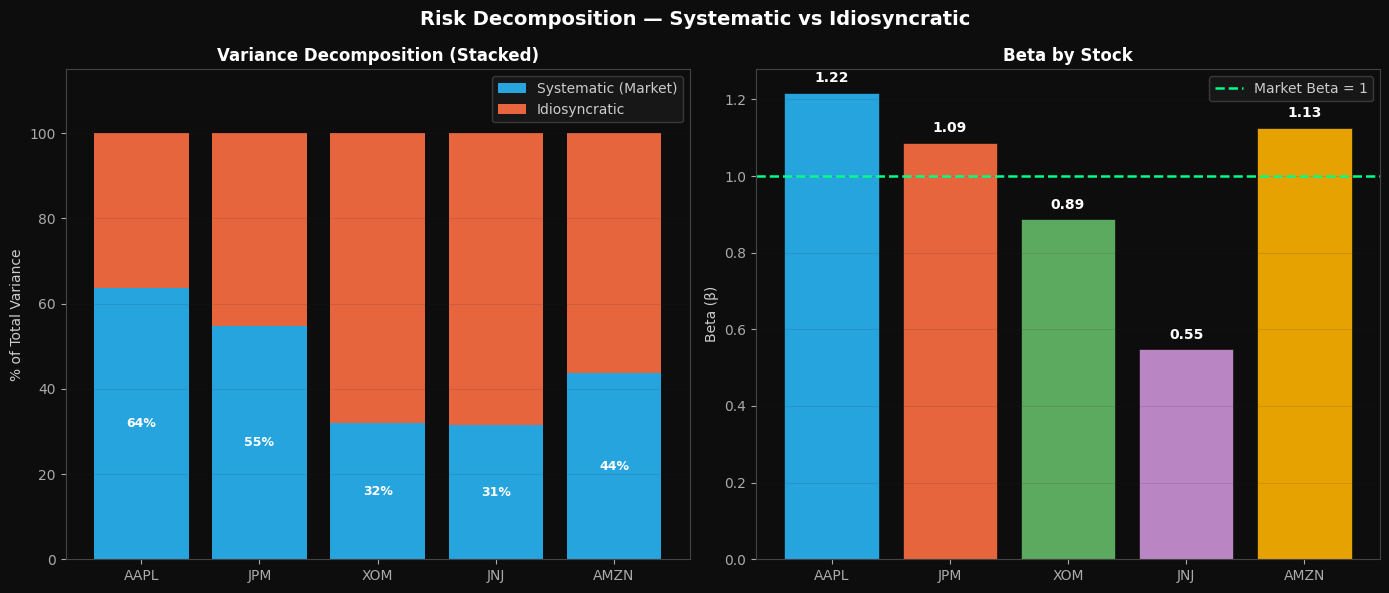

In [5]:
# ── Plot 2: Variance decomposition + Beta ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Risk Decomposition — Systematic vs Idiosyncratic',
             fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

sys_pcts  = [results[t]['sys_pct']  for t in TICKERS]
idio_pcts = [results[t]['idio_pct'] for t in TICKERS]
betas     = [results[t]['beta']     for t in TICKERS]

# Stacked bar
ax    = axes[0]
bars1 = ax.bar(TICKERS, sys_pcts,  color='#29B6F6',
               label='Systematic (Market)', alpha=0.9)
bars2 = ax.bar(TICKERS, idio_pcts, bottom=sys_pcts,
               color='#FF7043', label='Idiosyncratic', alpha=0.9)
ax.set_ylabel('% of Total Variance', color='#CCCCCC')
ax.set_title('Variance Decomposition (Stacked)', color='white', fontweight='bold')
ax.legend()
ax.set_ylim(0, 115)
ax.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars1, sys_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, v/2,
            f'{v:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=9)

# Beta chart
ax2  = axes[1]
bars = ax2.bar(TICKERS, betas,
               color=[STOCK_COLORS[t] for t in TICKERS],
               alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
ax2.axhline(1.0, color='#00FF88', linewidth=1.8,
            linestyle='--', label='Market Beta = 1')
ax2.set_ylabel('Beta (β)', color='#CCCCCC')
ax2.set_title('Beta by Stock', color='white', fontweight='bold')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars, betas):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
             f'{v:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.show()


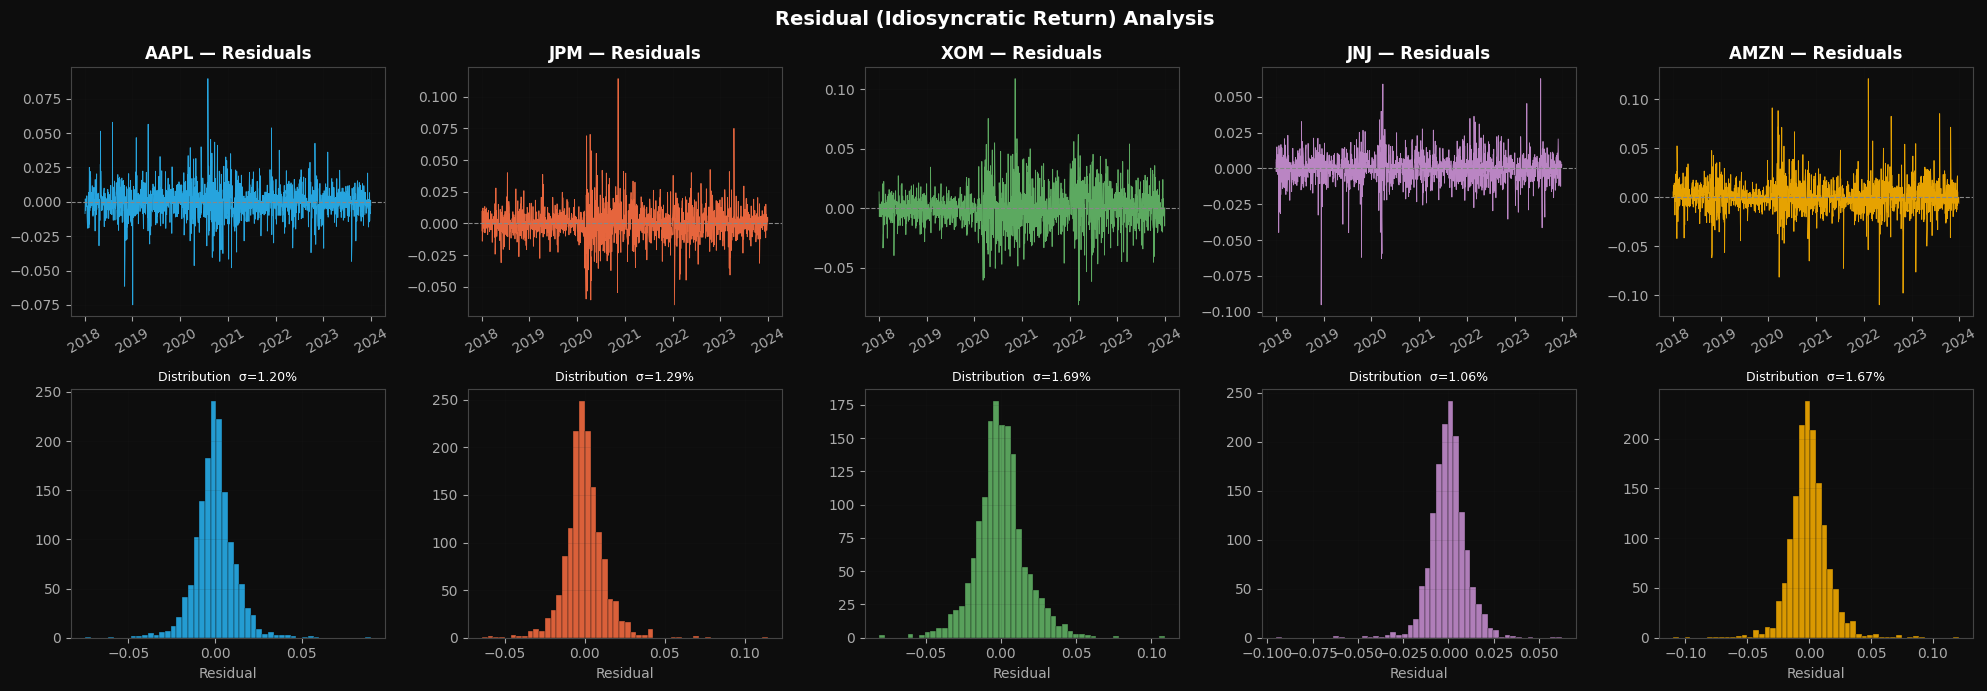

In [6]:
# ── Plot 3: Residual analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Residual (Idiosyncratic Return) Analysis',
             fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

for i, ticker in enumerate(TICKERS):
    resid = results[ticker]['residuals']

    ax_top = axes[0][i]
    ax_top.plot(resid.index, resid.values,
                color=STOCK_COLORS[ticker], linewidth=0.6, alpha=0.9)
    ax_top.axhline(0, color='#888888', linewidth=0.8, linestyle='--')
    ax_top.set_title(f'{ticker} — Residuals',
                     fontweight='bold', color='white')
    ax_top.tick_params(axis='x', rotation=30)
    ax_top.grid(True, alpha=0.12)

    ax_bot = axes[1][i]
    ax_bot.hist(resid, bins=50, color=STOCK_COLORS[ticker],
                alpha=0.85, edgecolor='#0D0D0D', linewidth=0.3)
    ax_bot.set_title(f'Distribution  σ={resid.std()*100:.2f}%',
                     fontsize=9, color='white')
    ax_bot.set_xlabel('Residual', color='#AAAAAA')
    ax_bot.grid(True, alpha=0.12)

plt.tight_layout()
plt.show()


## 5. Key Findings

In [7]:
print("=" * 60)
print("  SINGLE FACTOR BETA DECOMPOSITION — KEY FINDINGS")
print("=" * 60)

for ticker in TICKERS:
    r = results[ticker]
    print(f"\n{ticker}")
    print(f"  Beta            : {r['beta']:.3f}  ({'aggressive' if r['beta'] > 1 else 'defensive'})")
    print(f"  Alpha (daily)   : {r['alpha']*100:.4f}%")
    print(f"  R²              : {r['r_squared']:.3f}  ({r['r_squared']*100:.1f}% explained by market)")
    print(f"  Systematic risk : {r['sys_pct']:.1f}% of total variance")
    print(f"  Idiosync. risk  : {r['idio_pct']:.1f}% of total variance")

print("\n" + "=" * 60)
highest_beta = max(TICKERS, key=lambda t: results[t]['beta'])
lowest_beta  = min(TICKERS, key=lambda t: results[t]['beta'])
most_idio    = max(TICKERS, key=lambda t: results[t]['idio_pct'])
print(f"  Most market-sensitive : {highest_beta} (β={results[highest_beta]['beta']:.2f})")
print(f"  Most defensive        : {lowest_beta}  (β={results[lowest_beta]['beta']:.2f})")
print(f"  Most idiosyncratic    : {most_idio}  ({results[most_idio]['idio_pct']:.1f}% idio. risk)")
print("=" * 60)

  SINGLE FACTOR BETA DECOMPOSITION — KEY FINDINGS

AAPL
  Beta            : 1.218  (aggressive)
  Alpha (daily)   : 0.0569%
  R²              : 0.636  (63.6% explained by market)
  Systematic risk : 63.6% of total variance
  Idiosync. risk  : 36.4% of total variance

JPM
  Beta            : 1.086  (aggressive)
  Alpha (daily)   : 0.0006%
  R²              : 0.548  (54.8% explained by market)
  Systematic risk : 54.8% of total variance
  Idiosync. risk  : 45.2% of total variance

XOM
  Beta            : 0.887  (defensive)
  Alpha (daily)   : -0.0032%
  R²              : 0.319  (31.9% explained by market)
  Systematic risk : 31.9% of total variance
  Idiosync. risk  : 68.1% of total variance

JNJ
  Beta            : 0.548  (defensive)
  Alpha (daily)   : -0.0021%
  R²              : 0.315  (31.5% explained by market)
  Systematic risk : 31.5% of total variance
  Idiosync. risk  : 68.5% of total variance

AMZN
  Beta            : 1.126  (aggressive)
  Alpha (daily)   : 0.0196%
  R²       